# Native Qwen vs NOSE LoRA + Head

This demo uses the complete **274-term vocabulary** from the SI: Fruity (115), Green / Herbal (79), and Gourmand / Sweet (80).

- **Native Qwen:** unmodified Qwen3-Embedding-8B.
- **NOSE LoRA + Head:** current trained LoRA and contrastive descriptor head.


In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress")
import logging
logging.getLogger("Uni-Mol Tools").setLevel(logging.ERROR)
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import nose as nose_package
from nose import NOSEPipeline

ROOT = Path(nose_package.__file__).resolve().parents[1]
categories = json.loads((ROOT / "demos/assets/odor_space_categories.json").read_text())
words = [word for values in categories.values() for word in values]
labels = [label for label, values in categories.items() for _ in values]
CATEGORY_COLORS = {
    "Fruity": "#E91E63",
    "Green / Herbal": "#4CAF50",
    "Gourmand / Sweet": "#FF9800",
}

print(f"Complete vocabulary: {len(words)} terms")
for category, values in categories.items():
    print(f"  {category}: {len(values)}")
assert len(words) == 274

Complete vocabulary: 274 terms
  Fruity: 115
  Green / Herbal: 79
  Gourmand / Sweet: 80


In [2]:
pipeline = NOSEPipeline.from_pretrained()

base_embeddings = pipeline.encode_native(
    words,
    batch_size=32,
    normalize=False,
).numpy()
trained_embeddings = pipeline.encode_descriptors(
    words,
    batch_size=32,
    normalize=False,
).numpy()
label_ids = np.array([list(categories).index(label) for label in labels])

def pca_frame(embeddings, stage):
    pca = PCA(n_components=2, random_state=42)
    coordinates = pca.fit_transform(embeddings)
    frame = pd.DataFrame({
        "PC1": coordinates[:, 0],
        "PC2": coordinates[:, 1],
        "Descriptor": words,
        "Category": labels,
        "Stage": stage,
    })
    return frame, pca

base_frame, base_pca = pca_frame(base_embeddings, "Native Qwen")
trained_frame, trained_pca = pca_frame(trained_embeddings, "NOSE LoRA + Head")
silhouette = {
    "Native Qwen": silhouette_score(base_embeddings, label_ids, metric="cosine"),
    "NOSE LoRA + Head": silhouette_score(trained_embeddings, label_ids, metric="cosine"),
}
silhouette

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 54.95it/s]


{'Native Qwen': -0.016443856060504913, 'NOSE LoRA + Head': 0.36378607153892517}

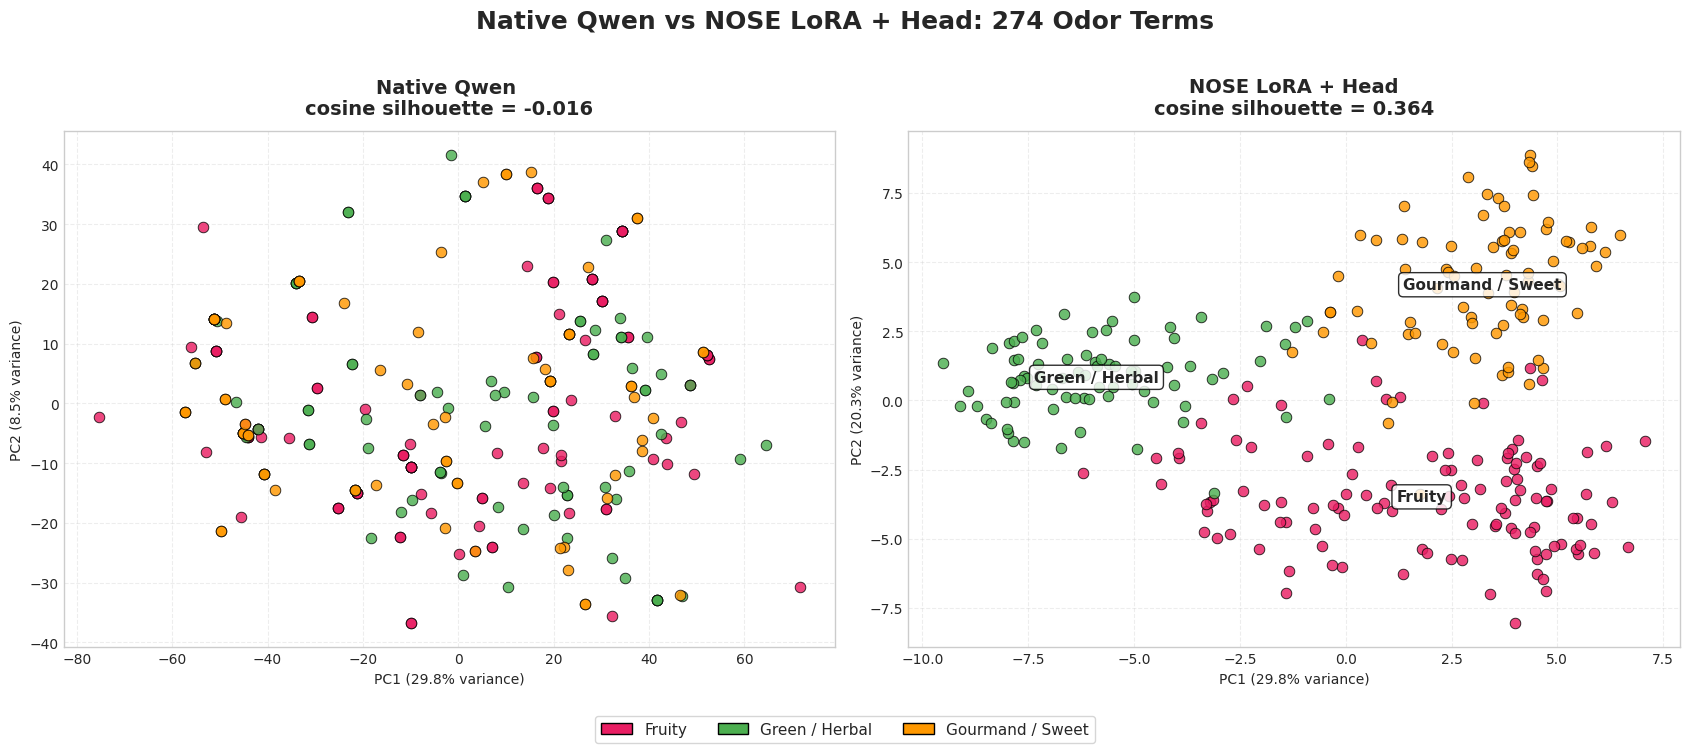

Direct interpretation: Native Qwen shows no category separation. NOSE LoRA + Head clearly clusters the three categories.


In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(17, 7.2))

# Left panel: Native Qwen - no category labels (categories are not separated)
for category in categories:
    subset = base_frame[base_frame["Category"] == category]
    axes[0].scatter(
        subset["PC1"], subset["PC2"],
        s=58, alpha=0.82, color=CATEGORY_COLORS[category],
        edgecolors="black", linewidth=0.65,
    )
axes[0].set_title(f"Native Qwen \ncosine silhouette = {silhouette['Native Qwen']:.3f}",
               fontsize=14, weight="bold", pad=12)
axes[0].set_xlabel(f"PC1 ({base_pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({base_pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
axes[0].grid(True, linestyle="--", alpha=0.35)

# Right panel: NOSE LoRA + Head - with category labels (clear separation)
for category in categories:
    subset = trained_frame[trained_frame["Category"] == category]
    axes[1].scatter(
        subset["PC1"], subset["PC2"],
        s=58, alpha=0.82, color=CATEGORY_COLORS[category],
        edgecolors="black", linewidth=0.65,
    )
    axes[1].text(
        subset["PC1"].mean(), subset["PC2"].mean(), category,
        fontsize=11, weight="bold", ha="center", va="center",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.82},
    )
axes[1].set_title(f"NOSE LoRA + Head\ncosine silhouette = {silhouette['NOSE LoRA + Head']:.3f}",
               fontsize=14, weight="bold", pad=12)
axes[1].set_xlabel(f"PC1 ({trained_pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({trained_pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
axes[1].grid(True, linestyle="--", alpha=0.35)

legend = [Patch(facecolor=color, edgecolor="black", label=label)
          for label, color in CATEGORY_COLORS.items()]
fig.legend(handles=legend, loc="lower center", ncol=3, frameon=True,
           bbox_to_anchor=(0.5, -0.01), fontsize=11)
fig.suptitle("Native Qwen vs NOSE LoRA + Head: 274 Odor Terms",
             fontsize=18, weight="bold", y=1.02)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

print("Direct interpretation: Native Qwen shows no category separation. NOSE LoRA + Head clearly clusters the three categories.")